In [ ]:
import pandas as pd

train_df=pd.read_csv('/content/train.csv')
test_df=pd.read_csv('/content/test.csv')

print(f'train: {train_df.shape}')
print(f'test: {test_df.shape}')

train: (1306122, 3)
test: (375806, 2)


In [ ]:
train_df.head(3)

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0


In [ ]:
train_df['target'].value_counts()

,count
target,
0,1225312
1,80810


### Сэмплирование
Для быстрого подбора гиперпараметров TF-IDF и обучения классических моделей берём стратифицированную выборку 100k примеров (по 50k на каждый класс).


In [ ]:
sample_size=100000

train_sample=train_df.groupby('target', group_keys=False).apply(
    lambda x: x.sample(min(len(x), sample_size//2), random_state=42)
).reset_index(drop=True)

print(f'размер сэмпла: {len(train_sample)}')
print(f'распределение классов:\n{train_sample['target'].value_counts()}\n')

размер сэмпла: 100000
распределение классов:
target
0    50000
1    50000
Name: count, dtype: int64



/tmp/ipykernel_1563/741626170.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_sample=train_df.groupby('target', group_keys=False).apply(


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_sample['question_text'],
    train_sample['target'],
    test_size=0.2,
    random_state=42,
    stratify=train_sample['target']
)

print(f'train size: {len(X_train)}')
print(f'val size: {len(X_val)}')
print(f'\ntrain target rate: {y_train.mean():.3f}')
print(f'val target_rate: {y_val.mean():.3f}')

train size: 80000
val size: 20000

train target rate: 0.500
val target_rate: 0.500


### Подбор гиперпараметров TF-IDF (GridSearchCV)

Перебираем параметры TF-IDF:
- максимальное количество признаков (max_features)
- диапазон n-грамм
- максимальную и минимальную частоту документа

Метрика - ROC-AUC, кросс-валидация 3 фолда.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report

ml_pipeline=Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english',)),
    ('clf', LogisticRegression(
        C=0.5,
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

tfidf_params={
    'tfidf__max_features': [25000, 30000, 40000],
    'tfidf__ngram_range': [(1,2), (1,3)],
    'tfidf__max_df':[0.7, 0.8, 0.9],
    'tfidf__min_df': [3,5]
}

tfidf_grid=GridSearchCV(
    ml_pipeline,
    tfidf_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

tfidf_grid.fit(X_train, y_train)

best_tfidf_params={
    'max_features': tfidf_grid.best_params_['tfidf__max_features'],
    'ngram_range': tfidf_grid.best_params_['tfidf__ngram_range'],
    'max_df': tfidf_grid.best_params_['tfidf__max_df'],
    'min_df': tfidf_grid.best_params_['tfidf__min_df']
}

print(f'лучшие параметры TF-IDF:')
print(f' max_features: {tfidf_grid.best_params_['tfidf__max_features']}')
print(f'ngram_range: {tfidf_grid.best_params_['tfidf__ngram_range']}')
print(f'max_df: {tfidf_grid.best_params_['tfidf__max_df']}')
print(f'min_df: {tfidf_grid.best_params_['tfidf__min_df']}')

Fitting 3 folds for each of 36 candidates, totalling 108 fits
лучшие параметры TF-IDF:
 max_features: 25000
ngram_range: (1, 2)
max_df: 0.7
min_df: 5


### Сравнение Logistic Regression и LightGBM

С фиксированными лучшими параметрами TF-IDF обучаем два алгоритма. Logistic Regression лучше работает на разреженных матрицах, LightGBM проверяем для сравнения.

In [ ]:
from lightgbm import LGBMClassifier


best_tfidf=TfidfVectorizer(
    max_features=tfidf_grid.best_params_['tfidf__max_features'],
    ngram_range=tfidf_grid.best_params_['tfidf__ngram_range'],
    max_df=tfidf_grid.best_params_['tfidf__max_df'],
    min_df=tfidf_grid.best_params_['tfidf__min_df'],
    stop_words='english'
)

X_train_tfidf=best_tfidf.fit_transform(X_train)
X_val_tfidf=best_tfidf.transform(X_val)


lr_params={
    'C':[0.1, 0.5, 1],
    'solver':['liblinear','lbfgs'],
    'class_weight': ['balanced', None]
}

lr_model=LogisticRegression(max_iter=1000, random_state=42)
lr_grid=GridSearchCV(
    lr_model,
    lr_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_tfidf, y_train)

print(f'Logistic Regression:')
print(f'лучшие параметры: {lr_grid.best_params_}')
print(f'лучший CV AUC: {lr_grid.best_score_:.3f}')

best_lr=lr_grid.best_estimator_
y_pred_lr=best_lr.predict_proba(X_val_tfidf)[:,1]
auc_lr=roc_auc_score(y_val, y_pred_lr)
print(f'ROC-AUC на валидации: {auc_lr:.3f}')


lgb_params={
    'n_estimators':[100,200],
    'max_depth':[7,10],
    'learning_rate': [0.05, 0.1],
    'num_leaves':[31, 50]
}

lgb_model=LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
lgb_grid=GridSearchCV(
    lgb_model,
    lgb_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print(f'\nLightGBM:')
lgb_grid.fit(X_train_tfidf, y_train)
print(f'лучшие параметры: {lgb_grid.best_params_}')
print(f'лучший CV AUC: {lgb_grid.best_score_:.3f}')

best_lgb=lgb_grid.best_estimator_
y_pred_lgb=best_lgb.predict_proba(X_val_tfidf)[:,1]
auc_lgb=roc_auc_score(y_val, y_pred_lgb)

print(f'ROC-AUC на валидации: {auc_lgb:.3f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Logistic Regression:
лучшие параметры: {'C': 1, 'class_weight': None, 'solver': 'liblinear'}
лучший CV AUC: 0.934
ROC-AUC на валидации: 0.940

LightGBM:
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


лучшие параметры: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}
лучший CV AUC: 0.909
ROC-AUC на валидации: 0.913


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
best_model=best_lr

y_pred_ml=best_model.predict(X_val_tfidf)
y_pred_prob_ml=best_model.predict_proba(X_val_tfidf)[:,1]

print(f'ROC-AUC: {roc_auc_score(y_val, y_pred_ml):.3f}')
print(f'\nclassification report:\n{classification_report(y_val, y_pred_ml, target_names=['sincere', 'insincere'])}')

ROC-AUC: 0.874

classification report:
              precision    recall  f1-score   support

     sincere       0.87      0.88      0.87     10000
   insincere       0.88      0.87      0.87     10000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000



### Анализ важности слов (коэффициенты LR)

Коэффициенты логистической регрессии показывают, какие слова сильнее всего влияют на предсказание.
- Положительные -> неискренность
- Отрицательные -> искренность

In [ ]:
import numpy as np

feature_names = best_tfidf.get_feature_names_out()
coefs = best_lr.coef_[0]

print('top-10 insincere:')
for i in np.argsort(coefs)[-10:]:
    print(f'  {feature_names[i]}: {coefs[i]:.3f}')

print(f'\ntop-10 sincere:')
for i in np.argsort(coefs)[:10]:
    print(f'  {feature_names[i]}: {coefs[i]:.3f}')

top-10 insincere:
  castrated: 6.200
  girls: 6.262
  jews: 6.349
  democrats: 7.486
  americans: 7.751
  women: 8.067
  muslims: 8.344
  indians: 8.351
  liberals: 8.410
  trump: 8.743

top-10 sincere:
  best: -3.384
  affect: -2.851
  tips: -2.645
  difference: -2.618
  study: -2.504
  engineering: -2.420
  company: -2.375
  characteristics: -2.355
  books: -2.245
  invest: -2.186


### Аугментация текста для BERT

С вероятностью 30% применяем простое преобразование: удаляем случайное слово или меняем местами два слова. Это увеличивает разнообразие обучающих примеров и снижает переобучение.

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from tqdm import tqdm

class QuoraDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_length=128, augment=False):
    self.texts=texts
    self.labels=labels
    self.tokenizer=tokenizer
    self.max_length=max_length
    self.augment=augment

  def augment_text(self,text):
    if not self.augment or np.random.random()>0.3:
      return text

    words=text.split()
    if len(words)<5:
      return text

    if np.random.random()>0.5:
      #удаление случайного слова
      i=np.random.randint(0,len(words))
      words.pop(i)
    else:
      # перестановка двух слов
      i1, i2= np.random.choice(len(words), 2, replace=False)
      words[i1], words[i2]=words[i2], words[i1]
    return ''.join(words)

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, i):
    text=str(self.texts[i])
    label=self.labels[i] if self.labels is not None else 0

    if self.augment:
      text=self.augment_text(text)

    encoding=self.tokenizer(text, max_length=self.max_length, truncation=True,
                            padding='max_length', return_tensors='pt')

    return {
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'labels': torch.tensor(label, dtype=torch.long)
    }

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

bert_sample_size=20000

train_bert_sample=train_df.groupby('target', group_keys=False).apply(
    lambda x: x.sample(min(len(x), bert_sample_size//2), random_state=42)
).reset_index(drop=True)

X_train_b, X_val_b, y_train_b, y_val_b=train_test_split(
    train_bert_sample['question_text'],
    train_bert_sample['target'],
    test_size=0.2,
    stratify=train_bert_sample['target']
)

print(f'bert train size: {len(X_train_b)}')
print(f'bert val size: {len(X_val_b)}\n')

bert train size: 16000
bert val size: 4000



/tmp/ipykernel_1563/190930726.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_bert_sample=train_df.groupby('target', group_keys=False).apply(


### Обучение BERT
- Модель: bert-base-uncased с dropout 0.2
- Оптимизатор: AdamW (lr=2e-5, weight_decay=0.01)
- Scheduler: линейный warmup (10% шагов)
- 3 эпохи, batch_size=32

Сохраняется лучшая модель по ROC-AUC на валидации

In [ ]:
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import roc_auc_score
from torch.optim import AdamW

tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')
model=BertForSequenceClassification.from_pretrained('bert-base-uncased',
                                                    num_labels=2,
                                                    hidden_dropout_prob=0.2,
                                                    attention_probs_dropout_prob=0.2
                                                    ).to(device)

train_dataset=QuoraDataset(X_train_b.tolist(), y_train_b.tolist(), tokenizer, augment=True)
val_dataset=QuoraDataset(X_val_b.tolist(), y_val_b.tolist(), tokenizer)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False)

num_epochs=3

optimizer=AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler=get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=(0.1*len(train_loader)*num_epochs),
    num_training_steps=len(train_loader)*num_epochs
)

train_losses=[]
val_losses=[]
val_aucs=[]

best_val_auc=0
for epoch in range(num_epochs):
  model.train()
  tr_loss=0
  for batch in tqdm(train_loader):
    optimizer.zero_grad()

    input_ids=batch['input_ids'].to(device)
    attention_mask=batch['attention_mask'].to(device)
    labels=batch['labels'].to(device)

    outputs=model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )
    loss=outputs.loss

    loss.backward()
    optimizer.step()
    scheduler.step()

    tr_loss+=loss.item()
  avg_tr_loss=tr_loss/len(train_loader)
  train_losses.append(avg_tr_loss)

  model.eval()
  val_loss=0
  preds=[]
  true_labels=[]
  with torch.no_grad():
    for batch in tqdm(val_loader):
      input_ids=batch['input_ids'].to(device)
      attention_mask=batch['attention_mask'].to(device)
      labels=batch['labels'].to(device)

      outputs=model(
          input_ids=input_ids,
          attention_mask=attention_mask,
          labels=labels)
      val_loss+=outputs.loss.item()

      probs=torch.softmax(outputs.logits,1)[:,1]

      preds.extend(probs.cpu().numpy())
      true_labels.extend(labels.cpu().numpy())
  avg_val_loss=val_loss/len(val_loader)
  val_auc=roc_auc_score(true_labels, preds)

  val_losses.append(avg_val_loss)
  val_aucs.append(val_auc)

  print(f'epoch {epoch+1}:')
  print(f'train loss = {avg_tr_loss:.3f}, val loss = {avg_val_loss:.3f}')
  print(f'val AUC: {val_auc:.3f}\n')

  if val_auc>best_val_auc:
    best_val_auc=val_auc
    torch.save(model.state_dict(), 'best_bert_model.pth')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

epoch 1:
train loss = 0.417, val loss = 0.282
val AUC: 0.958



100%|██████████| 125/125 [00:31<00:00,  4.02it/s]


epoch 2:
train loss = 0.308, val loss = 0.253
val AUC: 0.964



100%|██████████| 125/125 [00:31<00:00,  4.02it/s]


epoch 3:
train loss = 0.268, val loss = 0.246
val AUC: 0.965



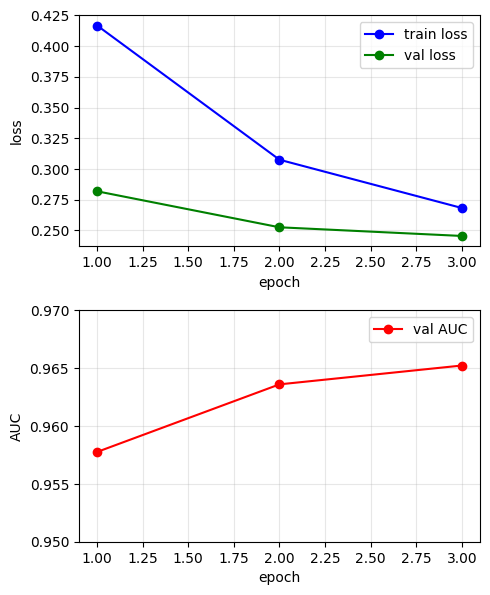

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,6))

plt.subplot(2,1,1)
plt.plot(range(1,num_epochs+1), train_losses, 'b-o', label='train loss')
plt.plot(range(1, num_epochs+1), val_losses, 'g-o', label = 'val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
plt.plot(range(1,num_epochs+1), val_aucs, 'r-o', label='val AUC')
plt.xlabel('epoch')
plt.ylabel('AUC')
plt.ylim(0.95, 0.97)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

In [ ]:
model.load_state_dict(torch.load('best_bert_model.pth'))

test_dataset=QuoraDataset(test_df['question_text'].tolist(), [0]*len(test_df), tokenizer)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

pred=[]
with torch.no_grad():
  for batch in tqdm(test_loader):
    input_ids=batch['input_ids'].to(device)
    attention_mask=batch['attention_mask'].to(device)

    outputs=model(input_ids=input_ids, attention_mask=attention_mask)
    probs=torch.softmax(outputs.logits, 1)[:,1]
    pred.extend(probs.cpu().numpy())

100%|██████████| 11744/11744 [48:47<00:00,  4.01it/s]


### Распределение предсказаний модели на тестовом наборе

Гистограмма показывает, как модель оценивает вероятность неискренности для тестовых вопросов.

- **Средняя вероятность = 0.163** - модель в среднемуверенна, что вопрос искренний
- **Доля предсказаний > 0.5 = 14.5%** - только у 14.5% тестовых вопросов вероятность неискренности выше порога

Это соответствует реальному распределению: в датасете неискренних вопросов ~17%, модель дала близкую оценку.

средняя вероятность: 0.163
доля>0.5: 0.145



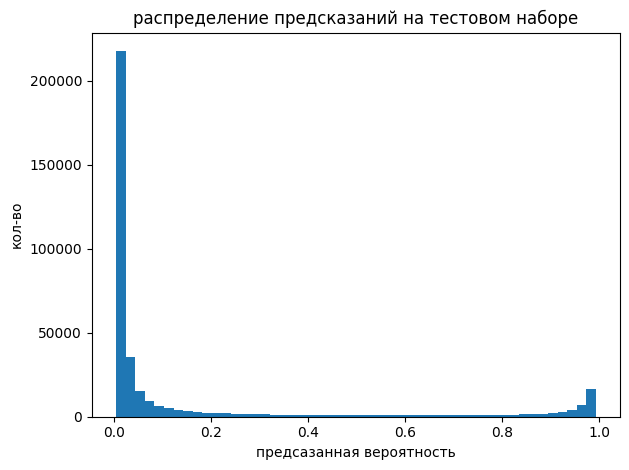

In [ ]:
plt.hist(pred, bins=50)
plt.xlabel('предсазанная вероятность')
plt.ylabel('кол-во')
plt.title('распределение предсказаний на тестовом наборе')
plt.tight_layout()

print(f"средняя вероятность: {np.mean(pred):.3f}")
print(f"доля>0.5: {np.mean(np.array(pred) > 0.5):.3f}\n")